<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_3_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Predicting Credit Default: Part 3
## Model Selection via Cross-Validation

**Author:** Brad Sheese

---

## Introduction: Picking the Winner

Up to this point, we have used logistic regression exclusively. But just as in our regression notebooks, there are many algorithms we can choose from—Decision Trees, Random Forests, Support Vector Machines (SVMs), and more.

In this notebook, we will use cross-validation to compare multiple model types and find the one that generalizes best to unseen data. We will also explore how regularization affects logistic regression's feature selection.

### Learning Objectives
By the end of this notebook, you will be able to:
1. Compare multiple model types using cross-validation with multiple scoring metrics.
2. Understand the trade-off between goodness of fit and model complexity.
3. See how regularization (L1, L2, ElasticNet) affects which features the model relies on.

## Section 1: Setup — The Credit Default Data

We'll start by loading our familiar Credit Default data one last time to compare different algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame
y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and ready for competition!")

Data loaded and ready for competition!


## Section 2: Model Competition via Cross-Validation

Just like in our Regression Part 2 notebook, we don't want to rely on a single train/test split. We will use 5-fold cross-validation to find the model that generalizes best to unseen data.

We will test four competitors:
1.  **Logistic Regression** — Our baseline (linear decision boundary)
2.  **Decision Tree (depth=3)** — Simple, interpretable rules
3.  **Random Forest (50 trees, depth=5)** — An ensemble of many trees
4.  **SVM (RBF kernel)** — Captures complex non-linear boundaries

We'll score each model on **both accuracy and F1** — because accuracy alone can be misleading on imbalanced data.

Logistic Regression      : Acc = 0.686 (+/- 0.020)  |  F1 = 0.556 (+/- 0.029)
Decision Tree (d=3)      : Acc = 0.636 (+/- 0.057)  |  F1 = 0.582 (+/- 0.037)


Random Forest            : Acc = 0.719 (+/- 0.032)  |  F1 = 0.574 (+/- 0.036)


SVM (RBF)                : Acc = 0.704 (+/- 0.031)  |  F1 = 0.567 (+/- 0.048)


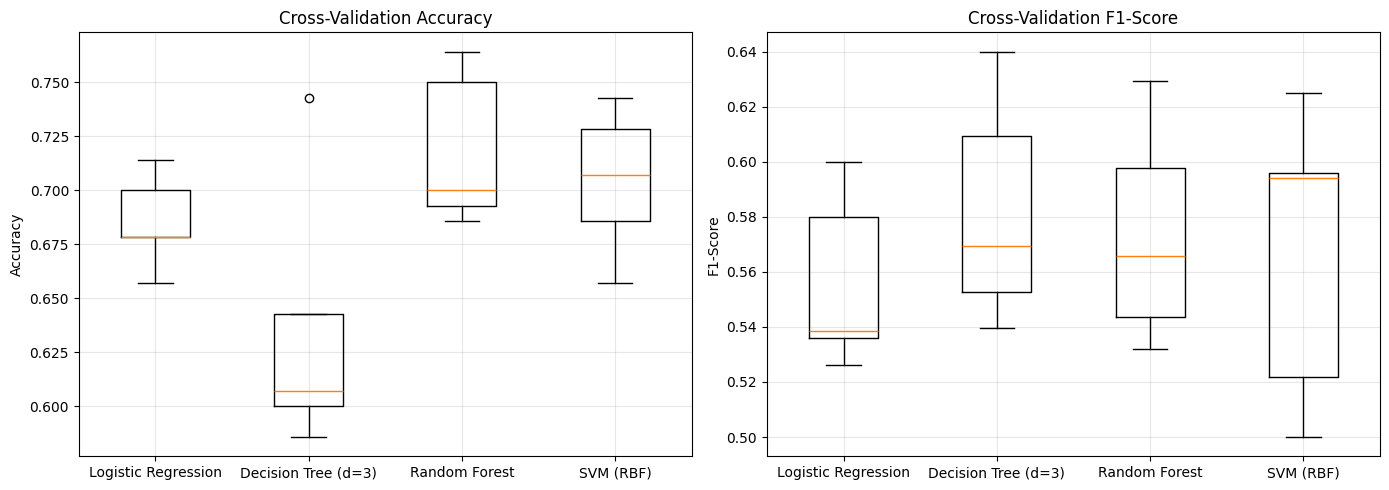

In [2]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), X_train_scaled),
    'Decision Tree (d=3)': (DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced'), X_train),
    'Random Forest': (RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, class_weight='balanced'), X_train),
    'SVM (RBF)': (SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'), X_train_scaled)
}

cv_accuracy = {}
cv_f1 = {}

for name, (model, X_feat) in models.items():
    acc_scores = cross_val_score(model, X_feat, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(model, X_feat, y_train, cv=5, scoring='f1')
    cv_accuracy[name] = acc_scores
    cv_f1[name] = f1_scores
    print(f"{name:<25}: Acc = {acc_scores.mean():.3f} (+/- {acc_scores.std():.3f})  |  F1 = {f1_scores.mean():.3f} (+/- {f1_scores.std():.3f})")

# Visualize both metrics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.boxplot(cv_accuracy.values(), tick_labels=cv_accuracy.keys())
ax1.set_title('Cross-Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)

ax2.boxplot(cv_f1.values(), tick_labels=cv_f1.keys())
ax2.set_title('Cross-Validation F1-Score')
ax2.set_ylabel('F1-Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting the Results

Look at both metrics together:

- **Accuracy** tells you the overall correctness. A model that gets all the majority class right but misses the minority class can still have high accuracy.
- **F1** tells you how well the model handles the minority class (defaults). A big gap between accuracy and F1 means the model is biased toward the majority class.

The **variance** (spread of each box) tells you how consistent the model is across different data splits. A wide box means the model's performance depends heavily on which specific samples end up in each fold — a sign of instability.

Notice that the Random Forest and SVM typically outperform the single Decision Tree. This is the power of ensembling (RF) and non-linear boundaries (SVM) over a single shallow tree.

## Section 3: Regularization and Feature Selection

Recall from our regression series: regularization penalizes large coefficients to prevent overfitting. In classification, the same principle applies.

Logistic regression supports three penalty types:
- **L2 (Ridge):** Shrinks all coefficients toward zero but rarely sets them exactly to zero.
- **L1 (Lasso):** Can set coefficients exactly to zero, effectively performing feature selection.
- **ElasticNet:** A mix of both L1 and L2.

Let's see how each penalty affects which features the model relies on.

/home/qwerty/repos/publiccourses/cs377/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/qwerty/repos/publiccourses/cs377/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/qwerty/repos/publiccourses/cs377/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values:

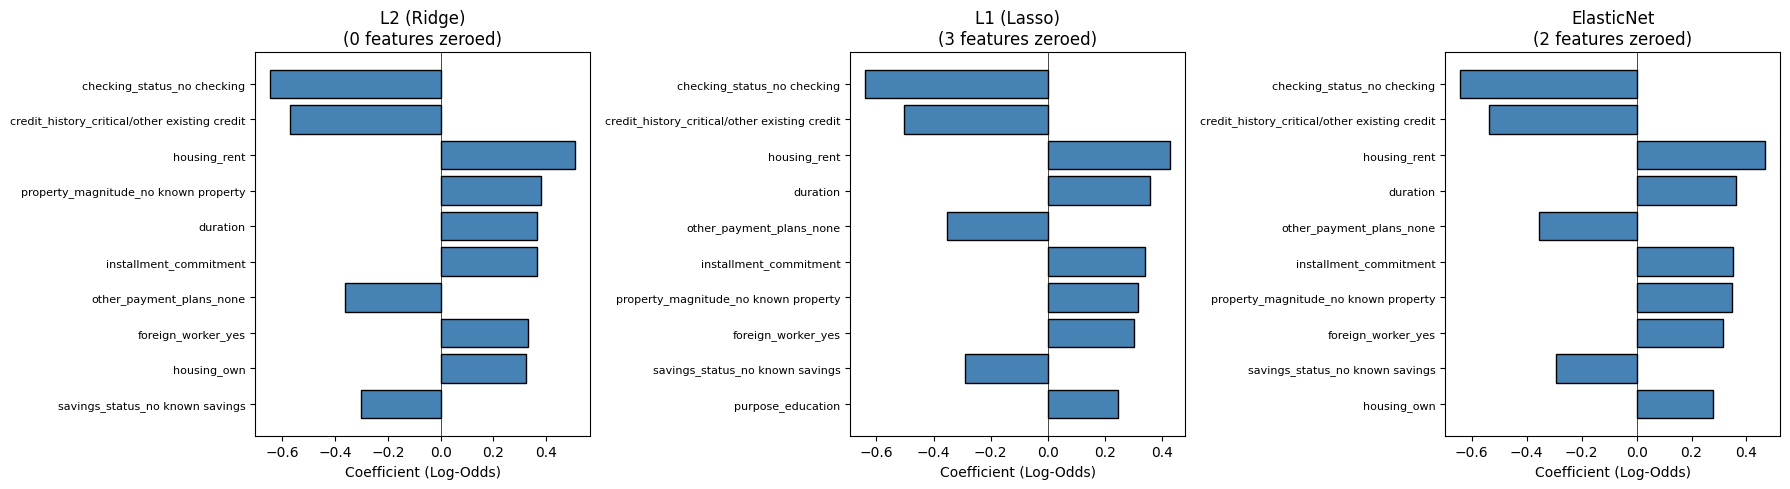

Features zeroed by each penalty:
  L2 (Ridge)     : 0 of 48 features zeroed
  L1 (Lasso)     : 3 of 48 features zeroed
  ElasticNet     : 2 of 48 features zeroed


/home/qwerty/repos/publiccourses/cs377/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/qwerty/repos/publiccourses/cs377/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/qwerty/repos/publiccourses/cs377/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values:

In [3]:
from sklearn.linear_model import LogisticRegression

penalties = {
    'L2 (Ridge)': LogisticRegression(max_iter=1000, penalty='l2', C=1.0, random_state=42, solver='lbfgs'),
    'L1 (Lasso)': LogisticRegression(max_iter=1000, penalty='l1', C=1.0, random_state=42, solver='saga'),
    'ElasticNet': LogisticRegression(max_iter=1000, penalty='elasticnet', C=1.0, l1_ratio=0.5, random_state=42, solver='saga')
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(penalties.items()):
    model.fit(X_train_scaled, y_train)
    coefs = model.coef_[0]
    n_zero = np.sum(np.abs(coefs) < 1e-5)
    
    # Sort by absolute coefficient
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    top_10 = sorted_idx[:10]
    
    axes[i].barh(range(len(top_10)), coefs[top_10], color='steelblue', edgecolor='black')
    axes[i].set_yticks(range(len(top_10)))
    axes[i].set_yticklabels([X_encoded.columns[j] for j in top_10], fontsize=8)
    axes[i].axvline(x=0, color='black', linewidth=0.5)
    axes[i].set_title(f'{name}\n({n_zero} features zeroed)')
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Coefficient (Log-Odds)')

plt.tight_layout()
plt.show()

print("Features zeroed by each penalty:")
for name, model in penalties.items():
    model.fit(X_train_scaled, y_train)
    n_zero = np.sum(np.abs(model.coef_[0]) < 1e-5)
    print(f"  {name:<15}: {n_zero} of {len(model.coef_[0])} features zeroed")

### What This Tells Us

- **L2 (Ridge)** shrinks coefficients but keeps all features. This is good when you believe all features contribute something, even if small.
- **L1 (Lasso)** actively zeroes out features, performing automatic feature selection. This is useful when you suspect many features are irrelevant.
- **ElasticNet** offers a middle ground — it can zero out features while still benefiting from L2's stability when features are correlated.

Notice that L1 and ElasticNet zero out different features. This tells you that feature selection is sensitive to the penalty type — there's no single "correct" subset of features.

### Your Turn

1. Add a 5th model to the competition (e.g., KNN with `n_neighbors=5`). Does it beat the others on F1? On accuracy?
2. Try changing the `C` parameter (inverse regularization strength) for L1 from 0.1 to 10. How does the number of zeroed features change?
3. The Random Forest has the lowest variance in the boxplot. Why might an ensemble be more stable than a single model?

## Conclusion

We've moved from evaluating a single model to comparing multiple algorithms. Key takeaways:

1. **Cross-validation with multiple metrics** is the gold standard for model comparison. Don't rely on accuracy alone.
2. **Variance matters** — a model with high mean but wide spread may be less reliable than a slightly lower but more consistent model.
3. **Regularization shapes feature selection** — L1 zeroes out features, L2 shrinks them all, and ElasticNet offers a middle ground.

So far we've worked with binary classification (good vs. bad credit). In the next notebook, we'll explore what happens when there are **3 or more classes** — and how models adapt to handle multiclass problems.